In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

Upload File

In [2]:
from google.colab import files
uploaded = files.upload()

Saving customer_shopping_data.csv to customer_shopping_data (1).csv


Load Data

In [3]:
df = pd.read_csv("customer_shopping_data.csv")
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


Understand Dataset

In [4]:
print(df.columns)
df.info()

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


Clean Column Names

In [5]:
df.columns = df.columns.str.strip().str.lower()

Create Total Spending Feature

In [6]:
df['total_spent'] = df['quantity'] * df['price']

Create Customer-Level Data

In [7]:
customer_data = df.groupby('customer_id').agg({
    'total_spent': 'sum',
    'quantity': 'sum'
}).reset_index()

Prepare Data for Clustering

In [8]:
X = customer_data[['total_spent', 'quantity']]

Elbow Method

In [9]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

Plot Elbow Graph

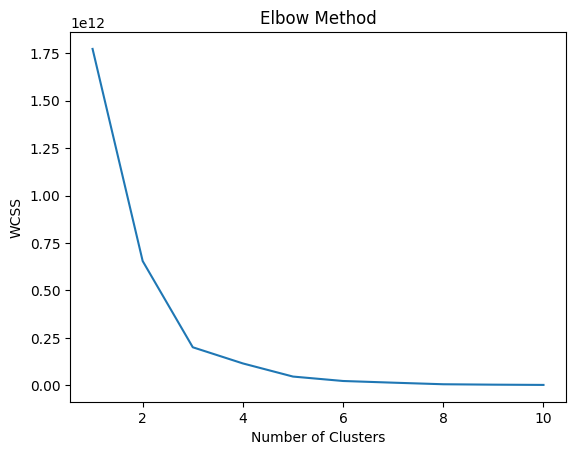

In [10]:
plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

Apply K-Means

In [11]:
kmeans = KMeans(n_clusters=5, random_state=42)
customer_data['cluster'] = kmeans.fit_predict(X)

Visualize Clusters

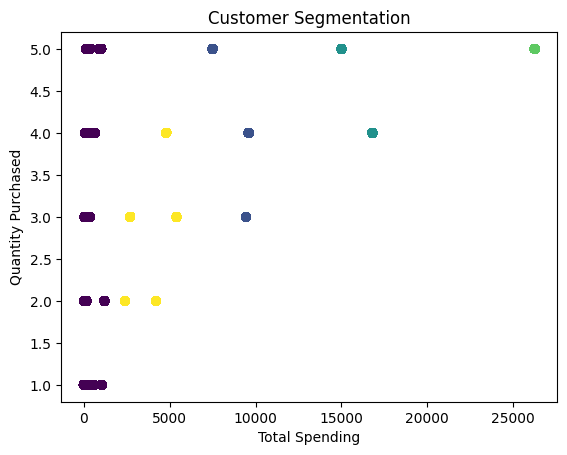

In [12]:
plt.scatter(customer_data['total_spent'], customer_data['quantity'],
            c=customer_data['cluster'])

plt.xlabel("Total Spending")
plt.ylabel("Quantity Purchased")
plt.title("Customer Segmentation")
plt.show()

In [13]:
customer_data.head()

,customer_id,total_spent,quantity,cluster
0,C100004,7502.00,5,1
1,C100005,2400.68,2,4
2,C100006,322.56,3,0
3,C100012,130.75,5,0
4,C100019,35.84,1,0


In [14]:
print(kmeans.cluster_centers_)

[[3.85377340e+02 2.60405041e+00]
 [8.12512585e+03 4.59482499e+00]
 [1.56006487e+04 4.66788321e+00]
 [2.62500000e+04 5.00000000e+00]
 [3.80119641e+03 3.20222210e+00]]
